# QuSpin Performance Benchmark

This notebook benchmarks the performance of the QuSpin-optimized Hamiltonian generation against the original Numpy implementation.

In [4]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the local module is importable
sys.path.append(os.getcwd())

import disentanglement as dis

%matplotlib inline

## Benchmarking Function

In [5]:
def benchmark_hamiltonian(generator_cls_numpy, generator_cls_quspin, sizes, **kwargs):
    results = []
    
    for N in sizes:
        print(f"Benchmarking N={N}...")
        
        # Numpy
        gen_np = generator_cls_numpy(N, **kwargs)
        start = time.time()
        _ = gen_np.generate()
        end = time.time()
        time_np = end - start
        
        # QuSpin
        gen_qs = generator_cls_quspin(N, **kwargs)
        start = time.time()
        _ = gen_qs.generate()
        end = time.time()
        time_qs = end - start
        
        results.append({
            "N": N,
            "Numpy (s)": time_np,
            "QuSpin (s)": time_qs,
            "Speedup": time_np / time_qs if time_qs > 0 else 0
        })
        
    return pd.DataFrame(results)

## 1. Central Spin Hamiltonian Benchmark

In [6]:
sizes = [4, 6, 8, 10]
df_central = benchmark_hamiltonian(
    dis.CentralSpinHamiltonianNumpy, 
    dis.CentralSpinHamiltonianQuSpin, 
    sizes, 
    Jx=1.0, Jz=1.0
)
print(df_central)

Benchmarking N=4...
Benchmarking N=6...


Benchmarking N=8...
Benchmarking N=10...
    N  Numpy (s)  QuSpin (s)     Speedup
0   4   0.006899    0.015558    0.443452
1   6   0.628360    0.018102   34.711851
2   8   3.064596    0.028154  108.850661
3  10  39.366948    0.099191  396.878535


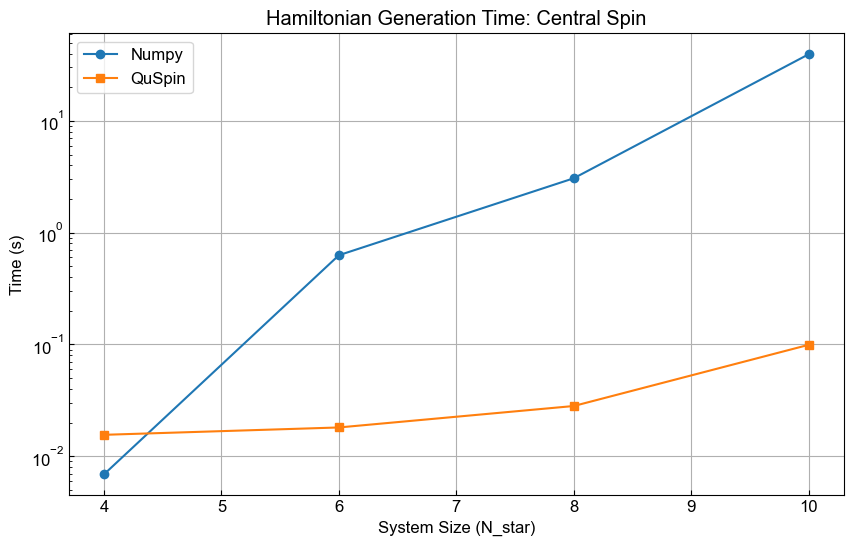

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_central["N"], df_central["Numpy (s)"], 'o-', label="Numpy")
plt.plot(df_central["N"], df_central["QuSpin (s)"], 's-', label="QuSpin")
plt.yscale("log")
plt.xlabel("System Size (N_star)")
plt.ylabel("Time (s)")
plt.title("Hamiltonian Generation Time: Central Spin")
plt.legend()
plt.grid(True)
plt.show()

## 2. Mixed Field Ising Hamiltonian Benchmark

In [11]:
sizes = [4, 5, 6, 7, 8, 9, 10, 11]
df_mixed = benchmark_hamiltonian(
    dis.MixedFieldIsingHamiltonianNumpy, 
    dis.MixedFieldIsingHamiltonianQuSpin, 
    sizes, 
    J=1.0, hx=0.5, hz=0.8
)
print(df_mixed)

Benchmarking N=4...
Benchmarking N=5...
Benchmarking N=6...
Benchmarking N=7...
Benchmarking N=8...
Benchmarking N=9...
Benchmarking N=10...
Benchmarking N=11...
    N  Numpy (s)  QuSpin (s)     Speedup
0   4   0.005980    0.013304    0.449506
1   5   0.015756    0.012197    1.291872
2   6   0.060977    0.022720    2.683824
3   7   0.155400    0.019022    8.169380
4   8   0.710970    0.024606   28.894471
5   9   0.707762    0.031928   22.167245
6  10   3.772761    0.074912   50.362840
7  11  15.874952    0.095693  165.893990


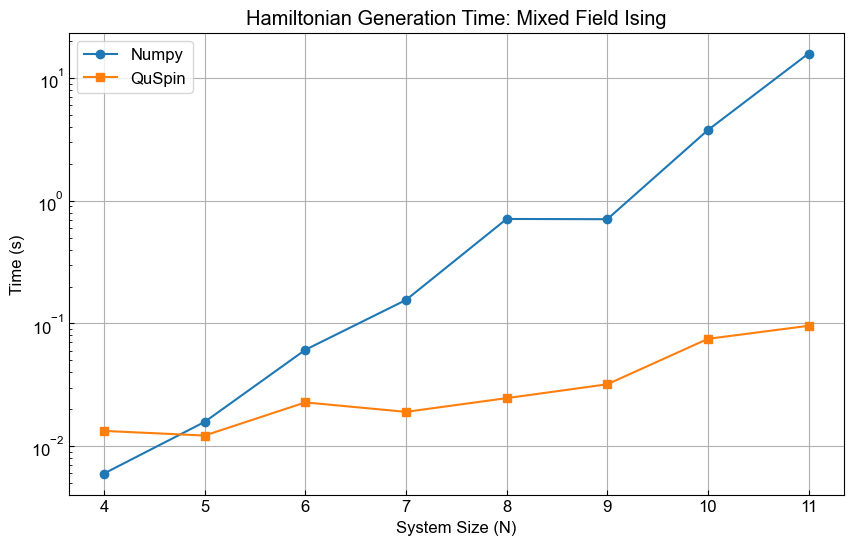

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(df_mixed["N"], df_mixed["Numpy (s)"], 'o-', label="Numpy")
plt.plot(df_mixed["N"], df_mixed["QuSpin (s)"], 's-', label="QuSpin")
plt.yscale("log")
plt.xlabel("System Size (N)")
plt.ylabel("Time (s)")
plt.title("Hamiltonian Generation Time: Mixed Field Ising")
plt.legend()
plt.grid(True)
plt.show()